In [55]:
pip install tensorflow pandas numpy scikit-learn matplotlib

#**1. Import Libraries**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,Input,Dropout

#**2. Load Dataset**

In [57]:
df = pd.read_csv("Language Detection.csv")

print(df.head())

                                                Text Language
0   Nature, in the broadest sense, is the natural...  English
1  "Nature" can refer to the phenomena of the phy...  English
2  The study of nature is a large, if not the onl...  English
3  Although humans are part of nature, human acti...  English
4  [1] The word nature is borrowed from the Old F...  English


#**3. Features and Labels**

In [58]:
X = df["Text"]
y = df["Language"]

#**4. Encode Labels**

In [59]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Languages:", encoder.classes_)

Languages: ['Arabic' 'Danish' 'Dutch' 'English' 'French' 'German' 'Greek' 'Hindi'
 'Italian' 'Kannada' 'Malayalam' 'Portugeese' 'Russian' 'Spanish'
 'Sweedish' 'Tamil' 'Turkish']


#**5. Tokenization**

In [60]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

#**6. Padding**

In [61]:
max_len = 40

X_pad = pad_sequences(X_seq, maxlen=max_len)

#**7. Train-Test Split**

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)


#**8. Build LSTM Model**

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

model = Sequential()

# Explicit Input Layer
model.add(Input(shape=(40,)))

# Embedding Layer
model.add(
    Embedding(
        input_dim=10000,
        output_dim=128
    )
)

# LSTM Layer
model.add(LSTM(128))

# Output Layer
model.add(Dense(17, activation='softmax'))

#**9. Compile Model**

In [73]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#**10. Model Summary**

In [74]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 40, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,777 (5.39 MB)

 Trainable params: 1,413,777 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

#**11. Train Model**

In [75]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.4979 - loss: 1.7686 - val_accuracy: 0.8786 - val_loss: 0.7160
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.9221 - loss: 0.3711 - val_accuracy: 0.9396 - val_loss: 0.2607
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.9601 - loss: 0.1734 - val_accuracy: 0.9560 - val_loss: 0.1836
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.9735 - loss: 0.1135 - val_accuracy: 0.9623 - val_loss: 0.1527
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.9764 - loss: 0.0947 - val_accuracy: 0.9570 - val_loss: 0.1612
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.9779 - loss: 0.0833 - val_accuracy: 0.9603 - val_loss: 0.1607
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9768 - loss: 0.0770 - val_accuracy: 0.9550 - val_loss: 0.1656
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.9765 - loss: 0

#**12. Evaluate Model**

In [76]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9570 - loss: 0.1587

Test Accuracy: 0.9569632411003113


#**13. Plot Accuracy**

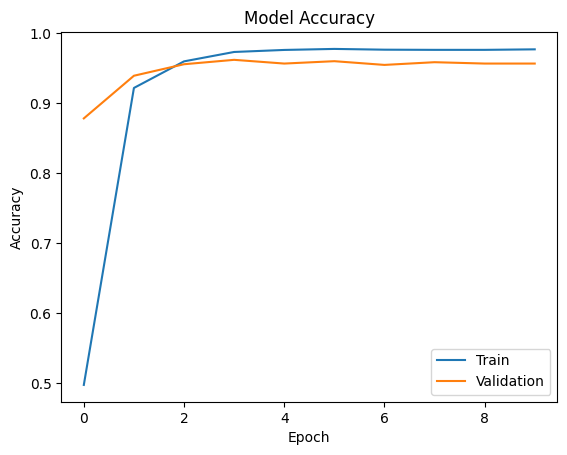

In [77]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

#**14. Prediction Function**

In [78]:
def predict_language(text):

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])

    # Pad sequence
    padded = pad_sequences(sequence, maxlen=max_len)

    # Predict
    prediction = model.predict(padded)

    # Get class index
    language_index = np.argmax(prediction)

    # Convert index to label
    language = encoder.inverse_transform([language_index])

    print(f"\nText: {text}")
    print("Predicted Language:", language[0])

#**15. Test Predictions**

In [79]:
predict_language("Bonjour mon ami")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step

Text: Bonjour mon ami
Predicted Language: French


In [80]:
predict_language("Hola amigo")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Text: Hola amigo
Predicted Language: Spanish


In [81]:
predict_language("How are you")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Text: How are you
Predicted Language: English


#**DEPLOYMENT**

In [83]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="AI Language Detector",
    page_icon="🌍",
    layout="centered"
)

# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

body {
    background-color: #0f172a;
}

.main {
    background: linear-gradient(to bottom right, #0f172a, #1e293b);
    color: white;
}

.title {
    font-size: 52px;
    font-weight: 800;
    text-align: center;
    color: #38bdf8;
    margin-top: 20px;
    margin-bottom: 10px;
}

.subtitle {
    text-align: center;
    color: #cbd5e1;
    font-size: 20px;
    margin-bottom: 35px;
}

.stTextArea textarea {
    background-color: #1e293b !important;
    color: white !important;
    border-radius: 18px !important;
    border: 2px solid #38bdf8 !important;
    font-size: 18px !important;
    padding: 15px !important;
}

.stButton button {
    width: 100%;
    background: linear-gradient(to right, #0ea5e9, #2563eb);
    color: white;
    font-size: 20px;
    font-weight: bold;
    border-radius: 15px;
    border: none;
    padding: 14px;
    transition: 0.3s;
}

.stButton button:hover {
    transform: scale(1.02);
    background: linear-gradient(to right, #2563eb, #0ea5e9);
}

.result-box {
    background: #1e293b;
    padding: 30px;
    border-radius: 20px;
    text-align: center;
    margin-top: 25px;
    border: 2px solid #38bdf8;
    box-shadow: 0px 0px 20px rgba(56,189,248,0.4);
}

.result-text {
    font-size: 32px;
    color: #38bdf8;
    font-weight: bold;
}

.confidence-text {
    font-size: 22px;
    color: white;
    margin-top: 12px;
}

.footer {
    text-align: center;
    color: gray;
    margin-top: 60px;
    font-size: 15px;
}

</style>
""", unsafe_allow_html=True)

# =========================================================
# LOAD MODEL
# =========================================================

model = load_model("language_model.h5")

tokenizer = pickle.load(open("tokenizer.pkl", "rb"))

encoder = pickle.load(open("encoder.pkl", "rb"))

# =========================================================
# HEADER
# =========================================================

st.markdown(
    '<div class="title">🌍 AI Language Detection System</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">Deep Learning Powered Multilingual Text Classifier</div>',
    unsafe_allow_html=True
)

# =========================================================
# INPUT AREA
# =========================================================

text = st.text_area(
    "✍️ Enter Your Text",
    height=200,
    placeholder="Type text here... Example: Bonjour mon ami"
)

# =========================================================
# PREDICTION FUNCTION
# =========================================================

max_len = 40

def predict_language(sentence):

    sequence = tokenizer.texts_to_sequences([sentence])

    padded = pad_sequences(sequence, maxlen=max_len)

    prediction = model.predict(padded)

    predicted_index = np.argmax(prediction)

    language = encoder.inverse_transform([predicted_index])[0]

    confidence = np.max(prediction) * 100

    return language, confidence

# =========================================================
# BUTTON
# =========================================================

if st.button("🚀 Detect Language"):

    if text.strip() == "":

        st.warning("⚠️ Please enter some text.")

    else:

        language, confidence = predict_language(text)

        # FLAGS
        flags = {
            "English": "🇺🇸",
            "French": "🇫🇷",
            "Spanish": "🇪🇸",
            "Hindi": "🇮🇳",
            "Italian": "🇮🇹",
            "Portuguese": "🇵🇹",
            "German": "🇩🇪",
            "Dutch": "🇳🇱",
            "Russian": "🇷🇺",
            "Turkish": "🇹🇷",
            "Arabic": "🇸🇦",
            "Swedish": "🇸🇪"
        }

        flag = flags.get(language, "🌐")

        st.markdown(
            f"""
            <div class="result-box">
                <div class="result-text">
                    {flag} {language}
                </div>

                <div class="confidence-text">
                    Confidence: {confidence:.2f}%
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("📌 About")

st.sidebar.info(
    """
This project uses:

✅ Deep Learning
✅ LSTM Neural Networks
✅ NLP Tokenization
✅ TensorFlow
✅ Streamlit Deployment

### Features
- Real-time prediction
- Multilingual detection
- Attractive UI
- Fast inference
"""
)

# =========================================================
# FOOTER
# =========================================================

st.markdown(
    """
    <div class="footer">
        Made with ❤️ using Streamlit & TensorFlow
    </div>
    """,
    unsafe_allow_html=True
)

Writing app.py


In [84]:
model.save("language_model.h5")

In [85]:
import pickle

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))

In [86]:
pickle.dump(encoder, open("encoder.pkl", "wb"))

In [87]:
##################################################
# SAVE MODEL
##################################################

model.save("language_model.h5")

##################################################
# SAVE TOKENIZER + ENCODER
##################################################

import pickle

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))

pickle.dump(encoder, open("encoder.pkl", "wb"))

print("Everything Saved Successfully!")

Everything Saved Successfully!
